In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import torch.nn as nn

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA

from simplexity.generative_processes.builder import build_hidden_markov_model
from simplexity.generative_processes.generator import generate_data_batch_with_full_history
from simplexity.utils.pytorch_utils import jax_to_torch
from src.hmm.hmm import belief_to_barycentric

from tqdm.auto import tqdm
import transformer_lens as tl

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
F.softmax(torch.tensor([0.1, 0.2, 0.7]), dim=-1)

tensor([0.2546, 0.2814, 0.4640])

## Parameters

In [4]:
from pathlib import Path

SEQ_LENGTH = 2000
HMM_CONCEPTS = ['E', 'Q', 'V']
N_SEQUENCES = 10

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

In [5]:
hmm = build_hidden_markov_model(
    "leopard",
    process_params={"x": 0.5},
    device=None,
)

## Build HMM & Generate Sequences

In [6]:
hmm = build_hidden_markov_model(
    "mess3",
    process_params={"x": 0.05, "a": 0.85},
    device=None,
)

print(f"Vocab size (symbols): {hmm.vocab_size}")
print(f"Num hidden states: {hmm.num_states}")
print(f"Initial state (belief): {jax_to_torch(hmm.initial_state).tolist()}")

emission_rows = []
for i in range(hmm.num_states):
    pure_state = jnp.zeros(hmm.num_states).at[i].set(1.0)
    obs_probs = hmm.observation_probability_distribution(pure_state)
    emission_rows.append(jax_to_torch(obs_probs))
emission_matrix = torch.stack(emission_rows)

print(f"\nEmission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")

Vocab size (symbols): 3
Num hidden states: 3
Initial state (belief): [0.33333343267440796, 0.3333333134651184, 0.33333325386047363]

Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1137, 0.7725, 0.1137],
        [0.1138, 0.1138, 0.7725]])

Row sums (should be 1): tensor([1., 1., 1.])


In [7]:
sequence_len = SEQ_LENGTH + 1
key = jax.random.PRNGKey(42)
gen_states = jnp.tile(hmm.initial_state, (N_SEQUENCES, 1))

gen_result = generate_data_batch_with_full_history(
    gen_states, hmm, N_SEQUENCES, sequence_len, key
)

inputs_jax = gen_result["inputs"]
belief_states_jax = gen_result["belief_states"]
labels_jax = gen_result["labels"]
prefix_probs = gen_result["prefix_probabilities"]

tokens = jax_to_torch(inputs_jax)
tokens_y = jax_to_torch(labels_jax)
belief_states_all = jax_to_torch(belief_states_jax).cpu().numpy()
obs_probs_all_jax = jnp.einsum('bns,vst->bnv', belief_states_jax, hmm.transition_matrices)
obs_probs_all = jax_to_torch(obs_probs_all_jax)

walk_concepts = [[HMM_CONCEPTS[int(t)] for t in seq] for seq in tokens]

print(f"Num sequences: {tokens.shape[0]}, Sequence length: {tokens.shape[1]}")
print(f"First 20 tokens (seq 0): {walk_concepts[0][:20]}")
print(f"Belief states shape: {belief_states_all.shape}")
print(f"Belief states sum to 1? {np.allclose(belief_states_all.sum(axis=-1), 1)}")

Num sequences: 10, Sequence length: 2000
First 20 tokens (seq 0): ['V', 'V', 'V', 'V', 'V', 'V', 'V', 'V', 'Q', 'Q', 'Q', 'E', 'V', 'V', 'E', 'V', 'V', 'V', 'E', 'Q']
Belief states shape: (10, 2000, 3)
Belief states sum to 1? True


In [8]:
obs_probs_all[0][:10]

tensor([[0.1632, 0.1632, 0.6737],
        [0.1221, 0.1221, 0.7558],
        [0.1177, 0.1177, 0.7646],
        [0.1173, 0.1173, 0.7654],
        [0.1173, 0.1173, 0.7655],
        [0.1173, 0.1173, 0.7655],
        [0.1173, 0.1173, 0.7655],
        [0.1173, 0.1173, 0.7655],
        [0.1367, 0.3742, 0.4891],
        [0.1243, 0.6914, 0.1843]])

### OBS prob not belief state

In [9]:
belief_to_barycentric(obs_probs_all.reshape(-1,3).cpu(), obs_probs_all.reshape(-1,3).cpu())

In [10]:
belief_to_barycentric(belief_states_all.reshape(-1,3), belief_states_all.reshape(-1,3))

## Load Model (TransformerLens)

In [11]:
MODEL_NAME = "meta-llama/Llama-3.2-3B"
N_DEVICES = min(torch.cuda.device_count(), 4)

print(f"Loading {MODEL_NAME} across {N_DEVICES} GPUs...")
model = tl.HookedTransformer.from_pretrained(
    MODEL_NAME,
    device="cuda",
    n_devices=N_DEVICES,
    torch_dtype=torch.float16,
    n_ctx=4098
)
model.eval()
print(f"Model loaded. {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
print(f"Context window: {model.cfg.n_ctx}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.2-3B across 4 GPUs...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.24it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded. 28 layers, d_model=3072
Context window: 4098


In [12]:
def get_concept_token_ids(model, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids = model.to_tokens(spaced, prepend_bos=False)[0]
        concept_to_id[concept] = ids[-1].item()
    return concept_to_id

In [13]:
belief_states_all[0]

array([[0.07500003, 0.07500001, 0.84999996],
       [0.01266352, 0.01266351, 0.974673  ],
       [0.00602964, 0.00602964, 0.98794067],
       ...,
       [0.98921233, 0.00542329, 0.00536437],
       [0.98930264, 0.00535115, 0.00534624],
       [0.9893109 , 0.00534472, 0.00534431]],
      shape=(2000, 3), dtype=float32)

## Forward Pass (with activation caching)

In [14]:
LAYERS_TO_ANALYZE = list(range(model.cfg.n_layers))
print(f"Will analyze layers: {LAYERS_TO_ANALYZE}")

letter_set = set(HMM_CONCEPTS)

all_activations = {layer: [] for layer in LAYERS_TO_ANALYZE}
all_logits = []
all_beliefs = []
all_positions = []

for seq_idx in tqdm(range(N_SEQUENCES), desc="Processing sequences"):
    seq_concepts = walk_concepts[seq_idx]
    beliefs = belief_states_all[seq_idx]

    prompt = seq_concepts[0] + " " + " ".join(seq_concepts[1:])
    input_ids = model.to_tokens(prompt, prepend_bos=True).to(model.embed.W_E.device)
    str_tokens = model.to_str_tokens(prompt, prepend_bos=True)

    positions = [i for i, tok in enumerate(str_tokens) if tok.strip() in letter_set]

    n_use = min(len(positions), len(seq_concepts))
    if len(positions) != len(seq_concepts):
        print(f"Warning seq {seq_idx}: expected {len(seq_concepts)} letter positions, got {len(positions)}")
    positions = positions[:n_use]

    with torch.no_grad():
        _, cache = model.run_with_cache(
            input_ids,
            names_filter=[f"blocks.{l}.hook_resid_post" for l in LAYERS_TO_ANALYZE],
            return_type=None,
        )

        for layer in LAYERS_TO_ANALYZE:
            hook_name = f"blocks.{layer}.hook_resid_post"
            layer_acts = cache[hook_name][0]
            letter_acts = layer_acts[positions].cpu().float().numpy()
            all_activations[layer].append(letter_acts)

        last_resid = cache[f"blocks.{LAYERS_TO_ANALYZE[-1]}.hook_resid_post"]
        last_resid = last_resid.to(model.unembed.W_U.device)
        logits = model.unembed(model.ln_final(last_resid))
        seq_logits = logits[0, positions].cpu().float().detach().numpy()
        all_logits.append(seq_logits)
        del logits, last_resid, cache

    all_beliefs.append(beliefs[:n_use + 1])
    all_positions.append(np.arange(n_use))
    torch.cuda.empty_cache()

for layer in LAYERS_TO_ANALYZE:
    all_activations[layer] = np.concatenate(all_activations[layer], axis=0)
all_logits_flat = np.concatenate(all_logits, axis=0)
all_beliefs_flat = np.concatenate(all_beliefs, axis=0)
all_positions_flat = np.concatenate(all_positions, axis=0)

print(f"\nTotal datapoints: {len(all_beliefs_flat)}")
print(f"Logits shape: {all_logits_flat.shape}")
print(f"Activations shape per layer: {all_activations[LAYERS_TO_ANALYZE[0]].shape}")
print(f"Beliefs shape: {all_beliefs_flat.shape}")
print(f"Position range: {all_positions_flat.min()} to {all_positions_flat.max()}")

Will analyze layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


Processing sequences:   0%|          | 0/10 [00:00<?, ?it/s]

Processing sequences: 100%|██████████| 10/10 [00:46<00:00,  4.67s/it]



Total datapoints: 20000
Logits shape: (20000, 128256)
Activations shape per layer: (20000, 3072)
Beliefs shape: (20000, 3)
Position range: 0 to 1999


## Concept Logits & KL Divergence

In [15]:
concept_to_id = get_concept_token_ids(model, HMM_CONCEPTS)
concept_ids = [concept_to_id[c] for c in HMM_CONCEPTS]
print(f"Concept token IDs (ordered): {dict(zip(HMM_CONCEPTS, concept_ids))}")

concept_logits = all_logits_flat[:, concept_ids]
llm_probs = F.softmax(torch.tensor(concept_logits), dim=-1).numpy()
llm_probs_all_vocab = F.softmax(torch.tensor(all_logits_flat), dim=-1)[:, concept_ids].numpy()

print(f"Concept logits shape: {concept_logits.shape}")
print(f"LLM probs shape: {llm_probs.shape}")

Concept token IDs (ordered): {'E': 469, 'Q': 1229, 'V': 650}
Concept logits shape: (20000, 3)
LLM probs shape: (20000, 3)


In [16]:
obs_probs_all.shape

torch.Size([10, 2000, 3])

In [17]:
def plot_kl_by_position(llm_probs_3d, hmm_probs, title_suffix="", ylim_top=None):
    """Plot KL(HMM || LLM) by sequence position with mean ± std across sequences."""
    eps = 1e-10
    p = np.clip(hmm_probs, eps, 1.0)
    q = np.clip(llm_probs_3d, eps, 1.0)

    kl_per_pos_seq = np.sum(p * np.log(p / q), axis=-1)
    kl_mean = kl_per_pos_seq.mean(axis=0)
    kl_std = kl_per_pos_seq.std(axis=0)

    fig, ax = plt.subplots(figsize=(12, 5))
    positions_arr = np.arange(kl_mean.shape[0])
    ax.plot(positions_arr, kl_mean, linewidth=0.8)
    ax.fill_between(positions_arr, kl_mean - kl_std, kl_mean + kl_std, alpha=0.2)
    ax.set_xlabel('Position in sequence')
    ax.set_ylabel('KL(HMM || LLM)')
    ax.set_title(f'KL Divergence: HMM observation probs vs LLM predicted probs{title_suffix}')
    ax.set_xscale('log')
    ax.set_xlim(1, kl_mean.shape[0])
    if ylim_top is not None:
        ax.set_ylim(None, ylim_top)
    plt.tight_layout()
    plt.show()

    print(f"Mean KL over all positions: {kl_mean.mean():.4f}")
    for i in [1, 10, 100, 1000, 1999]:
        if i < kl_mean.shape[0]:
            print(f"KL at position {i}: {kl_mean[i]:.4f}")
    return kl_mean

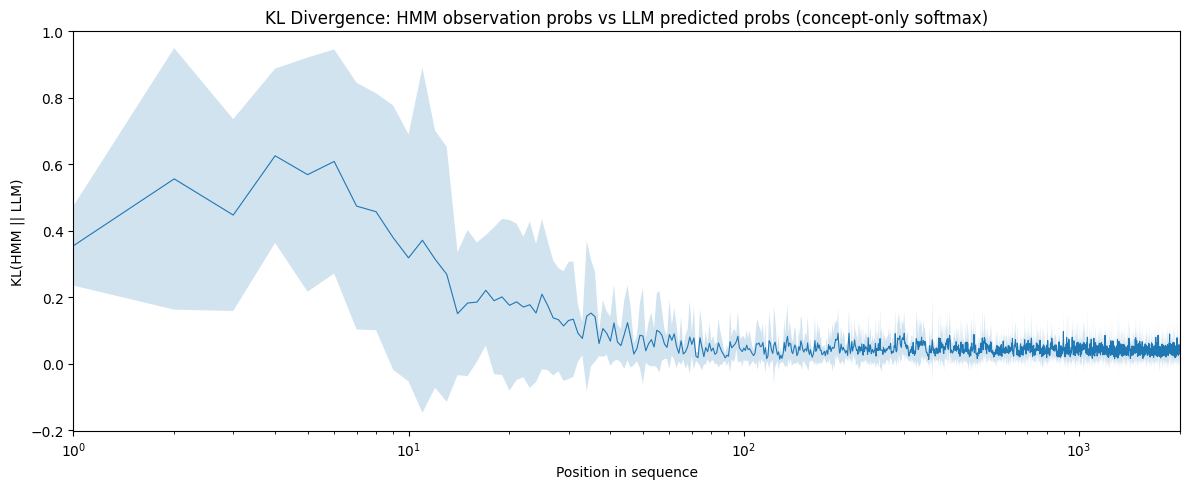

Mean KL over all positions: 0.0470
KL at position 1: 0.3545
KL at position 10: 0.3184
KL at position 100: 0.0469
KL at position 1000: 0.0458
KL at position 1999: 0.0410


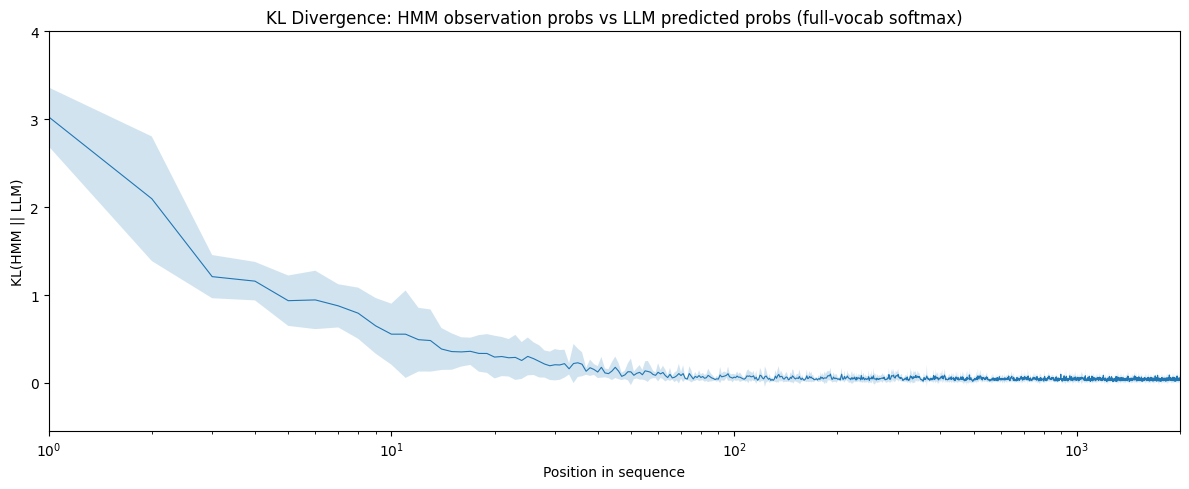

Mean KL over all positions: 0.0614
KL at position 1: 3.0270
KL at position 10: 0.5555
KL at position 100: 0.0670
KL at position 1000: 0.0486
KL at position 1999: 0.0429


array([9.727095  , 3.02701   , 2.0956786 , ..., 0.03711413, 0.04849416,
       0.04291128], shape=(2000,), dtype=float32)

In [18]:
hmm_probs = obs_probs_all[:, :, :].cpu().numpy()

# Softmax on concept logits only (conditional over {A,B,C})
llm_probs_3d = llm_probs.reshape(N_SEQUENCES, SEQ_LENGTH, len(HMM_CONCEPTS))
plot_kl_by_position(llm_probs_3d, hmm_probs, title_suffix=" (concept-only softmax)", ylim_top=1)

# Softmax on full vocab, then slice concept tokens
llm_probs_3d_all_vocab = llm_probs_all_vocab.reshape(N_SEQUENCES, SEQ_LENGTH, len(HMM_CONCEPTS))
plot_kl_by_position(llm_probs_3d_all_vocab, hmm_probs, title_suffix=" (full-vocab softmax)", ylim_top=4)

## Linear Probe: Belief State Regression

In [19]:
import pickle

CKPT_REGRESSION = CHECKPOINT_DIR / "regression_results.pkl"

if CKPT_REGRESSION.exists():
    print("Loading cached regression_results from disk...")
    with open(CKPT_REGRESSION, "rb") as f:
        regression_results = pickle.load(f)
    for layer in sorted(regression_results.keys()):
        r = regression_results[layer]
        print(f"Layer {layer:2d}: R² train={r['r2_train']:.6f}, R² test={r['r2_test']:.6f}")
else:
    regression_results = {}

    for layer in LAYERS_TO_ANALYZE:
        acts = all_activations[layer]
        beliefs = all_beliefs_flat

        X_train, X_test, y_train, y_test = train_test_split(
            acts, beliefs, test_size=0.2, random_state=42
        )

        reg = LinearRegression()
        reg.fit(X_train, y_train)

        y_pred_train = reg.predict(X_train)
        y_pred_test = reg.predict(X_test)

        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)

        projected = reg.predict(acts)

        regression_results[layer] = {
            'model': reg,
            'r2_train': r2_train,
            'r2_test': r2_test,
            'projected': projected,
        }

        print(f"Layer {layer:2d}: R² train={r2_train:.6f}, R² test={r2_test:.6f}")

    with open(CKPT_REGRESSION, "wb") as f:
        pickle.dump(regression_results, f)
    print(f"Saved to {CKPT_REGRESSION}")

Loading cached regression_results from disk...
Layer  0: R² train=0.989578, R² test=0.989259
Layer  1: R² train=0.997520, R² test=0.997381
Layer  2: R² train=0.998851, R² test=0.998679
Layer  3: R² train=0.999119, R² test=0.998855
Layer  4: R² train=0.999178, R² test=0.998841
Layer  5: R² train=0.999128, R² test=0.998528
Layer  6: R² train=0.998811, R² test=0.998154
Layer  7: R² train=0.998539, R² test=0.997552
Layer  8: R² train=0.998015, R² test=0.996425
Layer  9: R² train=0.997184, R² test=0.994996
Layer 10: R² train=0.996466, R² test=0.994121
Layer 11: R² train=0.996055, R² test=0.993329
Layer 12: R² train=0.995823, R² test=0.992734
Layer 13: R² train=0.995844, R² test=0.993297
Layer 14: R² train=0.995782, R² test=0.993350
Layer 15: R² train=0.995585, R² test=0.993454
Layer 16: R² train=0.995487, R² test=0.993643
Layer 17: R² train=0.995531, R² test=0.993587
Layer 18: R² train=0.995116, R² test=0.993339
Layer 19: R² train=0.995135, R² test=0.993293
Layer 20: R² train=0.995053, R² t

In [20]:
regression_results_main = regression_results

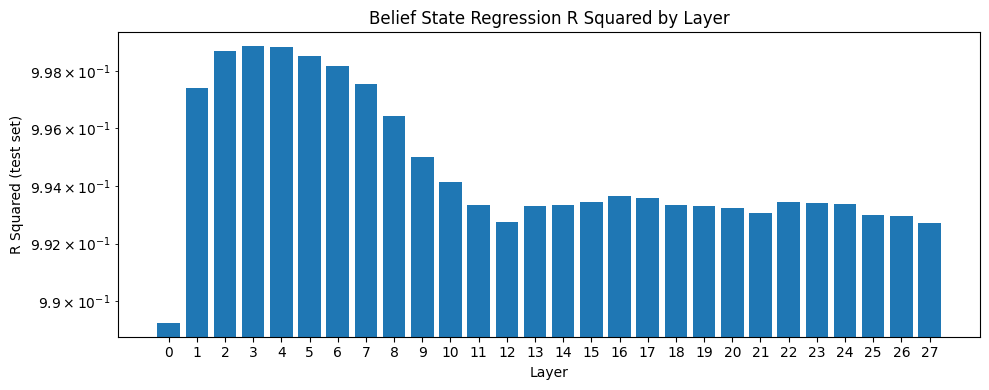

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
r2_values = [regression_results[l]['r2_test'] for l in layers]

ax.bar(range(len(layers)), r2_values, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('R Squared (test set)')
ax.set_title('Belief State Regression R Squared by Layer')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Logit Lens & Tuned Logit Lens

Apply the **logit lens** and **tuned logit lens** to each layer's residual stream and compute KL divergence against HMM observation probabilities.

- **Logit lens**: directly apply `ln_final` + `unembed` to each intermediate hidden state (no training).
- **Tuned logit lens**: learn a per-layer affine translator `T_l: h_l → h̃` before applying `ln_final` + `unembed`. The translator is trained to match the model's full output distribution over concept tokens.

In [22]:
# Align HMM observation probabilities with the flat activations.
#
# obs_probs_all[b, t] = P(next token | belief at step t) for the HMM
# The activation at concept position t predicts the (t+1)-th concept token.
# Therefore we align with obs_probs_all[:, 1:SEQ_LENGTH+1, :].
#
# Shapes:
#   obs_probs_all : (N_SEQUENCES, SEQ_LENGTH+1, 3)  -- HMM vocab size is 3
#   hmm_probs_flat: (N_SEQUENCES * SEQ_LENGTH, 3)   -- aligned with all_activations

hmm_probs_flat = obs_probs_all[:, :SEQ_LENGTH + 1, :].cpu().numpy().reshape(-1, 3)

print(f"HMM probs shape : {hmm_probs_flat.shape}")
print(f"Row-sum check   : min={hmm_probs_flat.sum(1).min():.6f}, max={hmm_probs_flat.sum(1).max():.6f}")
print(f"Concept IDs (A,B,C): {concept_ids}")

HMM probs shape : (20000, 3)
Row-sum check   : min=1.000000, max=1.000000
Concept IDs (A,B,C): [469, 1229, 650]


In [23]:
model.unembed.W_U.shape, model.unembed.b_U.shape

(torch.Size([3072, 128256]), torch.Size([128256]))

In [56]:
import torch.nn as nn

_unembed_device = model.unembed.W_U.device
W_concept = model.unembed.W_U[:, concept_ids].detach()   # (d_model, K)
b_concept = model.unembed.b_U[concept_ids].detach()       # (K,)

# 1e-10 is below fp16 denorm (~6e-8), causing log(p/0) = inf after fp16 roundtrip.
# Use 1e-8 so clipping is effective even on fp16-origin values.
_EPS = 1e-8
_BATCH = 1024


def compute_logit_lens(all_activations, all_logits_flat, concept_ids, hmm_probs_flat,
                       layers, model, softmax_mode="concept_only"):
    """
    Compute logit lens probabilities and KL divergences.

    softmax_mode:
        "concept_only" - softmax over concept logits only (conditional P over concepts)
        "full_vocab"   - softmax over full vocab, then slice concept ids
    """
    if softmax_mode == "concept_only":
        model_concept_probs = F.softmax(
            torch.tensor(all_logits_flat[:, concept_ids], dtype=torch.float32), dim=-1
        ).numpy()
    else:
        model_concept_probs = F.softmax(
            torch.tensor(all_logits_flat, dtype=torch.float32), dim=-1
        )[:, concept_ids].numpy()

    lens_probs   = {}
    kl_mean      = {}
    kl_all       = {}
    kl_vs_model_mean = {}

    with torch.no_grad():
        for layer in tqdm(layers, desc=f"Logit lens ({softmax_mode})"):
            acts = torch.tensor(all_activations[layer], dtype=torch.float32)
            n    = acts.shape[0]
            probs_list = []

            for start in range(0, n, _BATCH):
                batch = acts[start : start + _BATCH].to(_unembed_device)
                normed        = model.ln_final(batch)
                concept_logit = normed @ W_concept + b_concept
                probs_list.append(F.softmax(concept_logit, dim=-1).cpu().numpy())

            probs = np.concatenate(probs_list, axis=0)
            lens_probs[layer] = probs

            q = np.clip(probs / probs.sum(1, keepdims=True), _EPS, 1.0)

            # KL(HMM || lens)
            p   = np.clip(hmm_probs_flat, _EPS, 1.0)
            kl  = np.sum(p * np.log(p / q), axis=-1)
            kl_mean[layer] = float(kl.mean())
            kl_all[layer]  = kl

            # KL(model || lens)
            p_m = np.clip(model_concept_probs, _EPS, 1.0)
            kl_m = np.sum(p_m * np.log(p_m / q), axis=-1)
            kl_vs_model_mean[layer] = float(kl_m.mean())

        torch.cuda.empty_cache()

    return lens_probs, kl_mean, kl_all, kl_vs_model_mean, model_concept_probs


def plot_logit_lens_comparison(layers_sorted, kl_mean, kl_vs_model_mean, r2_by_layer, title_suffix=""):
    """Plot logit lens KL and R² comparison."""
    kl_logit = [kl_mean[l] for l in layers_sorted]
    kl_logit_vs_model = [kl_vs_model_mean[l] for l in layers_sorted]
    r2_vals = [r2_by_layer[l] for l in layers_sorted]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(layers_sorted, kl_logit, "o-", color="darkorange", linewidth=2, label="KL(HMM ‖ lens)")
    ax.plot(layers_sorted, kl_logit_vs_model, "o-", color="steelblue", linewidth=2, label="KL(model ‖ lens)")
    ax.axhline(kl_mean[layers_sorted[-1]], color="grey", linestyle="--", linewidth=1,
               label=f"Model output final KL (layer {layers_sorted[-1]})")
    ax.set_xlabel("Layer"); ax.set_ylabel("KL")
    ax.set_title(f"Logit-Lens KL Divergence vs HMM by Layer{title_suffix}")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax1 = axes[1]; ax2 = ax1.twinx()
    ax1.plot(layers_sorted, r2_vals, "o-", color="steelblue", linewidth=2, label="R² (linear probe)")
    ax2.plot(layers_sorted, kl_logit, "s--", color="darkorange", linewidth=2, label="KL – logit lens")
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("R² (linear probe → belief state)", color="steelblue")
    ax2.set_ylabel("KL(HMM ‖ lens)", color="darkorange")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax1.set_title("Belief-State R² vs Logit-Lens KL per Layer")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
    ax1.grid(True, alpha=0.3)

    plt.suptitle(f"Logit Lens – Llama-3.2-3B on Mess3 HMM (a=0.85, x=0.05){title_suffix}",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Layer':>5}  {'R²':>10}    {'KL logit':>10}    {'KL logit vs model':>10}")
    print("-" * 50)
    for i, l in enumerate(layers_sorted):
        print(f"{l:5d}  {r2_vals[i]:10.5f}  {kl_logit[i]:10.5f}   {kl_logit_vs_model[i]:10.5f}")
    return fig

Logit lens (concept_only):   0%|          | 0/28 [00:00<?, ?it/s]

Logit lens (concept_only): 100%|██████████| 28/28 [00:02<00:00, 12.33it/s]


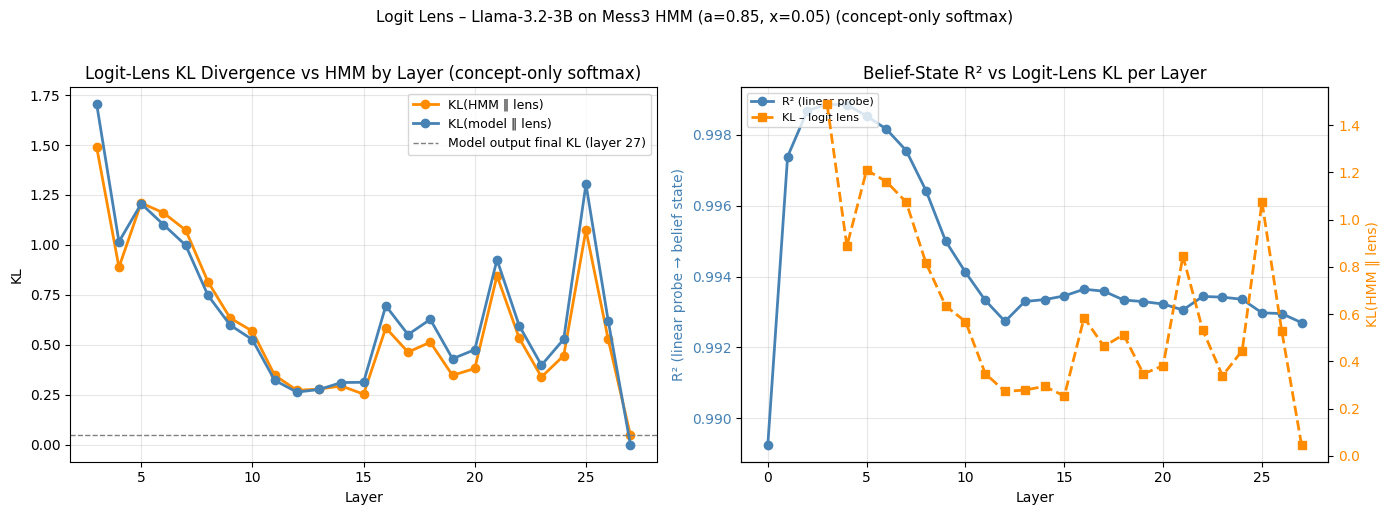


Layer          R²      KL logit    KL logit vs model
--------------------------------------------------
    0     0.98926         inf          inf
    1     0.99738         inf          inf
    2     0.99868         inf          inf
    3     0.99885     1.48823      1.70378
    4     0.99884     0.88822      1.01606
    5     0.99853     1.21000      1.20631
    6     0.99815     1.16082      1.10182
    7     0.99755     1.07429      0.99866
    8     0.99642     0.81641      0.74829
    9     0.99500     0.63399      0.59888
   10     0.99412     0.56851      0.52575
   11     0.99333     0.34815      0.32263
   12     0.99273     0.27232      0.26324
   13     0.99330     0.27849      0.27639
   14     0.99335     0.29402      0.31109
   15     0.99345     0.25312      0.31256
   16     0.99364     0.58508      0.69550
   17     0.99359     0.46336      0.55125
   18     0.99334     0.51316      0.62748
   19     0.99329     0.34703      0.43026
   20     0.99322     0.38158      

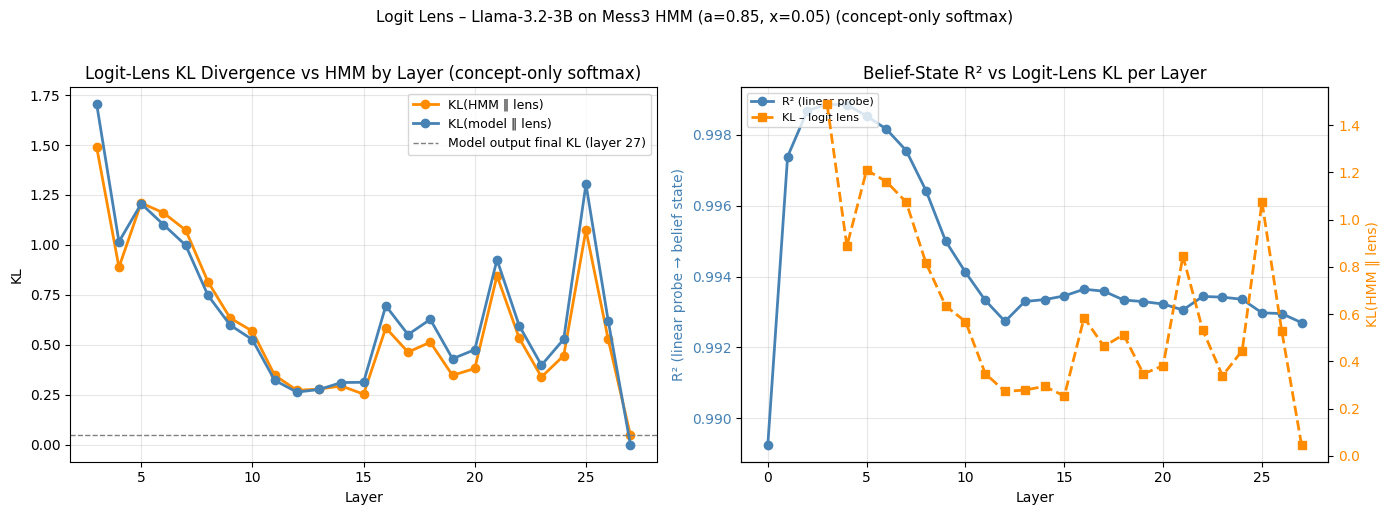

In [25]:
# Concept-only softmax logit lens
(logit_lens_probs, logit_lens_kl_mean, logit_lens_kl_all,
 logit_lens_kl_vs_model_mean, _model_concept_probs) = compute_logit_lens(
    all_activations, all_logits_flat, concept_ids, hmm_probs_flat,
    LAYERS_TO_ANALYZE, model, softmax_mode="concept_only"
)

r2_by_layer = {l: regression_results_main[l]['r2_test'] for l in LAYERS_TO_ANALYZE}
plot_logit_lens_comparison(sorted(LAYERS_TO_ANALYZE), logit_lens_kl_mean,
                           logit_lens_kl_vs_model_mean, r2_by_layer,
                           title_suffix=" (concept-only softmax)")

### Logit lens, softmax on entire vocab

In [26]:
# Full-vocab softmax logit lens
(logit_lens_probs_fv, logit_lens_kl_mean_fv, logit_lens_kl_all_fv,
 logit_lens_kl_vs_model_mean_fv, _model_concept_probs_fv) = compute_logit_lens(
    all_activations, all_logits_flat, concept_ids, hmm_probs_flat,
    LAYERS_TO_ANALYZE, model, softmax_mode="full_vocab"
)

Logit lens (full_vocab): 100%|██████████| 28/28 [00:02<00:00, 11.18it/s]


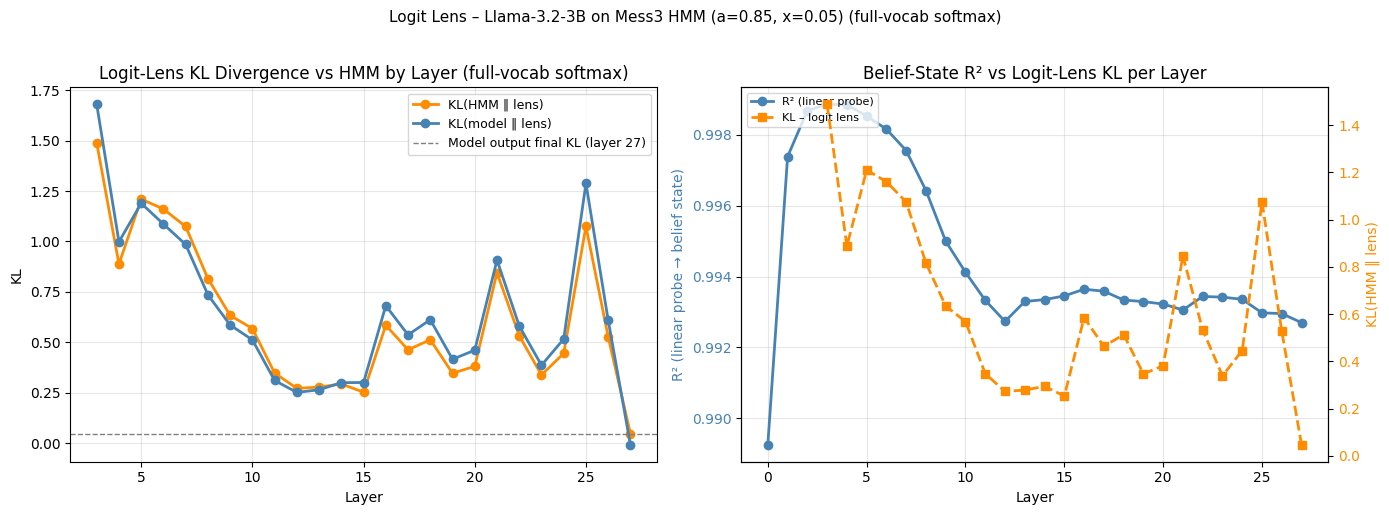


Layer          R²      KL logit    KL logit vs model
--------------------------------------------------
    0     0.98926         inf          inf
    1     0.99738         inf          inf
    2     0.99868         inf          inf
    3     0.99885     1.48823      1.67947
    4     0.99884     0.88822      0.99845
    5     0.99853     1.21000      1.18932
    6     0.99815     1.16082      1.08629
    7     0.99755     1.07429      0.98507
    8     0.99642     0.81641      0.73583
    9     0.99500     0.63399      0.58606
   10     0.99412     0.56851      0.51266
   11     0.99333     0.34815      0.31136
   12     0.99273     0.27232      0.25218
   13     0.99330     0.27849      0.26534
   14     0.99335     0.29402      0.30048
   15     0.99345     0.25312      0.30128
   16     0.99364     0.58508      0.68191
   17     0.99359     0.46336      0.53747
   18     0.99334     0.51316      0.61231
   19     0.99329     0.34703      0.41661
   20     0.99322     0.38158      

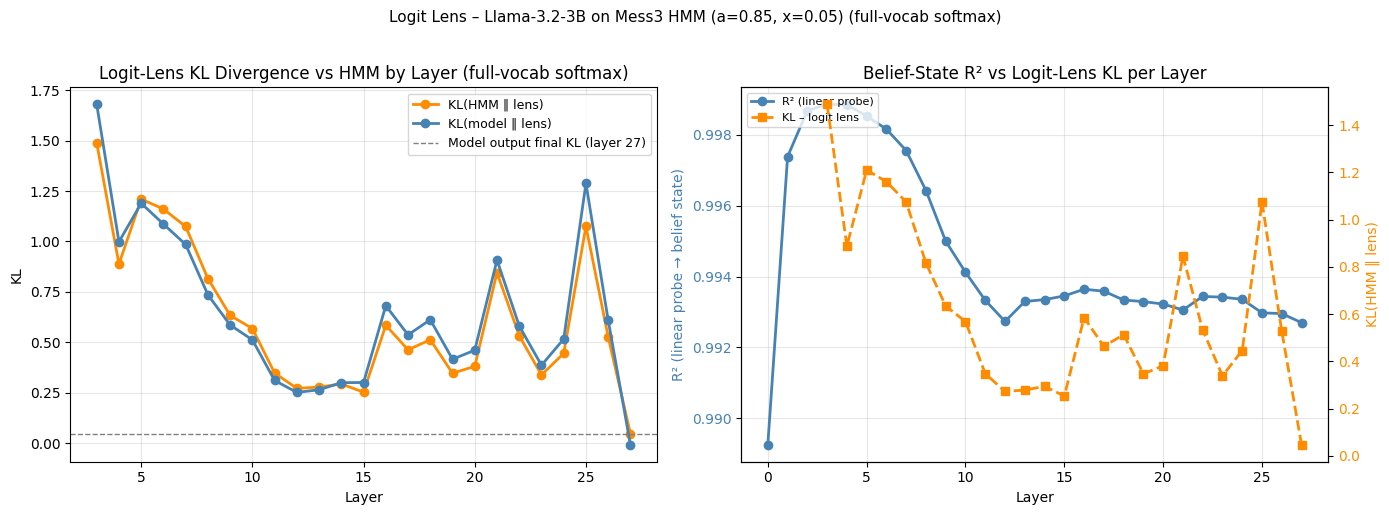

In [27]:
plot_logit_lens_comparison(sorted(LAYERS_TO_ANALYZE), logit_lens_kl_mean_fv,
                           logit_lens_kl_vs_model_mean_fv, r2_by_layer,
                           title_suffix=" (full-vocab softmax)")

## Tuned Lens

In [28]:
# ─── Tuned Logit Lens ───────────────────────────────────────────────────────
# Per-layer affine translator  T_l : R^{d_model} → R^{d_model}
# Initialized as the identity so training starts from the logit-lens baseline.
# Trained to minimise KL( model_concept_probs ‖ tuned_lens_concept_probs ).

class TunedLensTranslator(nn.Module):
    """Affine map h_l → h̃, initialized as identity."""

    def __init__(self, d_model: int):
        super().__init__()
        self.linear = nn.Linear(d_model, d_model, bias=True)
        nn.init.eye_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


def train_tuned_lens(
    all_activations,
    model,
    concept_ids,
    layers,
    target_concept_values_flat,   # logits if target_is_probs=False, probs if True
    target_is_probs: bool = False,
    n_epochs: int = 50,
    lr: float = 1e-3,
    batch_size: int = 512,
):
    """
    Train one translator per layer so that
        softmax(unembed(ln_final(T_l(h_l)))[concept_ids])
    matches the target concept-token distribution.
    """
    device   = model.unembed.W_U.device
    d_model  = model.cfg.d_model

    W_c = model.unembed.W_U[:, concept_ids].detach().to(device)
    b_c = model.unembed.b_U[concept_ids].detach().to(device)

    target = torch.as_tensor(target_concept_values_flat, dtype=torch.float32)
    if target_is_probs:
        target_probs = target
    else:
        target_probs = F.softmax(target, dim=-1)

    translators  = {}
    all_losses   = {}

    for layer in tqdm(layers, desc="Training tuned lens"):
        acts = torch.tensor(all_activations[layer], dtype=torch.float32)
        n    = acts.shape[0]

        translator = TunedLensTranslator(d_model).to(device)
        optimizer  = torch.optim.Adam(translator.parameters(), lr=lr)
        scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

        epoch_losses = []
        for epoch in range(n_epochs):
            perm       = torch.randperm(n)
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, batch_size):
                idx           = perm[start : start + batch_size]
                acts_batch    = acts[idx].to(device)
                target_batch  = target_probs[idx].to(device)

                optimizer.zero_grad()

                h             = translator(acts_batch)
                normed        = model.ln_final(h)
                concept_logit = normed @ W_c + b_c
                log_probs     = F.log_softmax(concept_logit, dim=-1)

                loss = F.kl_div(log_probs, target_batch, reduction="batchmean")
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            epoch_losses.append(epoch_loss / n_batches)

        translators[layer] = translator.cpu().eval()
        for p in translators[layer].parameters():
            p.requires_grad = False
        all_losses[layer]  = epoch_losses
        torch.cuda.empty_cache()

    return translators, all_losses

### For all vocab with threading to distribute over gpus

In [29]:
import threading
import copy
import time

def train_tuned_lens_full_vocab(
    all_activations,
    all_logits_flat,
    model,
    layers,
    n_epochs: int = 50,
    lr: float = 1e-3,
    batch_size: int = 256,
):
    """
    Train full-vocab tuned lens across multiple GPUs.

    Model is sharded across all 8 GPUs. Logits stay on CPU.
    Target softmax is pre-computed once and stored as fp16 in pinned memory
    so per-batch transfers are fast (~62 MB/batch) and no redundant GPU softmax.
    """
    n_gpus_total = torch.cuda.device_count()
    worker_gpus = [torch.device(f"cuda:{i}") for i in range(1, n_gpus_total)]
    n_workers = len(worker_gpus)
    assert n_workers > 0, f"Need at least 2 GPUs, found {n_gpus_total}"

    print(f"Found {n_gpus_total} GPUs, using {n_workers} workers: {worker_gpus}")
    print(f"  cuda:0 — model primary shard (skip)")

    # Pre-compute softmax on CPU in chunks, store as fp16 pinned for fast DMA
    print("Pre-computing target softmax on CPU (fp16 pinned)...")
    t0 = time.time()
    n_total = all_logits_flat.shape[0]
    vocab_size = all_logits_flat.shape[1]
    target_probs_cpu = torch.empty(n_total, vocab_size, dtype=torch.float16, pin_memory=True)
    _chunk = 1024
    for s in range(0, n_total, _chunk):
        chunk = torch.tensor(all_logits_flat[s:s+_chunk], dtype=torch.float32)
        target_probs_cpu[s:s+_chunk] = F.softmax(chunk, dim=-1).half()
    print(f"  Done in {time.time()-t0:.1f}s, "
          f"{target_probs_cpu.nbytes/1e9:.1f} GB pinned CPU memory")

    # Copy frozen unembed weights + ln_final to each worker GPU
    W_U_per_gpu = {}
    b_U_per_gpu = {}
    ln_final_per_gpu = {}
    for gpu in worker_gpus:
        W_U_per_gpu[gpu] = model.unembed.W_U.detach().clone().to(gpu)
        b_U_per_gpu[gpu] = model.unembed.b_U.detach().clone().to(gpu)
        ln_final_per_gpu[gpu] = copy.deepcopy(model.ln_final).to(gpu)
        print(f"  {gpu}: W_U + ln_final copied, "
              f"{torch.cuda.memory_allocated(gpu)/1e9:.1f} GB used")

    translators = {}
    all_losses  = {}
    lock        = threading.Lock()

    pbar = tqdm(total=len(layers) * n_epochs, desc="Full-vocab tuned lens", unit="epoch")

    def train_layer(layer, gpu):
        W_U      = W_U_per_gpu[gpu]
        b_U      = b_U_per_gpu[gpu]
        ln_final = ln_final_per_gpu[gpu]

        acts = torch.tensor(all_activations[layer], dtype=torch.float32, device=gpu)
        n    = acts.shape[0]

        translator = TunedLensTranslator(model.cfg.d_model).to(gpu)
        optimizer  = torch.optim.Adam(translator.parameters(), lr=lr)
        scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

        epoch_losses = []
        for epoch in range(n_epochs):
            perm       = torch.randperm(n)
            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, n, batch_size):
                idx        = perm[start : start + batch_size]
                acts_batch = acts[idx.to(gpu)]

                # Pre-computed fp16 softmax, pinned→GPU DMA, cast to fp32 on GPU
                target_batch = target_probs_cpu[idx].to(gpu, non_blocking=True).float()

                optimizer.zero_grad()
                h         = translator(acts_batch)
                normed    = ln_final(h)
                logits    = normed @ W_U + b_U
                log_probs = F.log_softmax(logits, dim=-1)
                loss      = F.kl_div(log_probs, target_batch, reduction="batchmean")
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            epoch_losses.append(epoch_loss / n_batches)
            pbar.update(1)
            pbar.set_postfix(gpu=str(gpu), layer=layer, epoch=epoch,
                             loss=f"{epoch_losses[-1]:.4f}")

        translator_cpu = translator.cpu().eval()
        for p in translator_cpu.parameters():
            p.requires_grad = False

        with lock:
            translators[layer] = translator_cpu
            all_losses[layer]  = epoch_losses

        del acts
        torch.cuda.empty_cache()

    def train_layers_on_gpu(gpu, layer_list):
        for layer in layer_list:
            train_layer(layer, gpu)

    # Split layers round-robin across workers
    layer_chunks = {gpu: [] for gpu in worker_gpus}
    for i, layer in enumerate(layers):
        gpu = worker_gpus[i % n_workers]
        layer_chunks[gpu].append(layer)

    for gpu, chunk in layer_chunks.items():
        print(f"  {gpu}: {len(chunk)} layers — {chunk}")

    # One thread per GPU; layers sequential within, GPUs parallel across
    threads = []
    for gpu in worker_gpus:
        t = threading.Thread(target=train_layers_on_gpu, args=(gpu, layer_chunks[gpu]))
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    pbar.close()

    del target_probs_cpu, W_U_per_gpu, b_U_per_gpu, ln_final_per_gpu
    torch.cuda.empty_cache()

    return translators, all_losses

In [30]:
# ─── Train full-vocab tuned lens ────────────────────────────────────────────
print(f"\nTraining full-vocab tuned lens (d_model={model.cfg.d_model}, vocab_size={model.cfg.d_vocab})")

tuned_lens_translators_fv, losses_fv = train_tuned_lens_full_vocab(
    all_activations, all_logits_flat, model, LAYERS_TO_ANALYZE,
    n_epochs=50, lr=1e-3, batch_size=256,
)


Training full-vocab tuned lens (d_model=3072, vocab_size=128256)
Found 8 GPUs, using 7 workers: [device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3), device(type='cuda', index=4), device(type='cuda', index=5), device(type='cuda', index=6), device(type='cuda', index=7)]
  cuda:0 — model primary shard (skip)
Pre-computing target softmax on CPU (fp16 pinned)...
  Done in 8.0s, 5.1 GB pinned CPU memory
  cuda:1: W_U + ln_final copied, 2.7 GB used
  cuda:2: W_U + ln_final copied, 2.8 GB used
  cuda:3: W_U + ln_final copied, 2.8 GB used
  cuda:4: W_U + ln_final copied, 0.8 GB used
  cuda:5: W_U + ln_final copied, 0.8 GB used
  cuda:6: W_U + ln_final copied, 0.8 GB used
  cuda:7: W_U + ln_final copied, 0.8 GB used


Full-vocab tuned lens:   0%|          | 0/1400 [00:00<?, ?epoch/s]

  cuda:1: 4 layers — [0, 7, 14, 21]
  cuda:2: 4 layers — [1, 8, 15, 22]
  cuda:3: 4 layers — [2, 9, 16, 23]
  cuda:4: 4 layers — [3, 10, 17, 24]
  cuda:5: 4 layers — [4, 11, 18, 25]
  cuda:6: 4 layers — [5, 12, 19, 26]
  cuda:7: 4 layers — [6, 13, 20, 27]


Full-vocab tuned lens: 100%|██████████| 1400/1400 [39:19<00:00,  1.69s/epoch, epoch=49, gpu=cuda:1, layer=21, loss=0.0042]


In [44]:
import json

CKPT_MODEL = CHECKPOINT_DIR / "tuned_lens_model.pt"
CKPT_LOSSES_MODEL = CHECKPOINT_DIR / "tuned_lens_model_losses.json"
CKPT_HMM = CHECKPOINT_DIR / "tuned_lens_hmm.pt"
CKPT_LOSSES_HMM = CHECKPOINT_DIR / "tuned_lens_hmm_losses.json"
CKPT_FV = CHECKPOINT_DIR / "tuned_lens_full_vocab.pt"
CKPT_LOSSES_FV = CHECKPOINT_DIR / "tuned_lens_full_vocab_losses.json"

_model_concept_logits = all_logits_flat[:, concept_ids]
print(f"Model concept logits shape: {_model_concept_logits.shape}")

# --- model-target translators ---
if CKPT_MODEL.exists():
    print("Loading cached tuned_lens_translators from disk...")
    tuned_lens_translators = torch.load(CKPT_MODEL, weights_only=False)
    with open(CKPT_LOSSES_MODEL) as f:
        training_losses = {int(k): v for k, v in json.load(f).items()}
else:
    tuned_lens_translators, training_losses = train_tuned_lens(
        all_activations, model, concept_ids, LAYERS_TO_ANALYZE,
        _model_concept_logits, target_is_probs=False, n_epochs=50, lr=1e-3, batch_size=512,
    )
    torch.save(tuned_lens_translators, CKPT_MODEL)
    with open(CKPT_LOSSES_MODEL, "w") as f:
        json.dump({str(k): v for k, v in training_losses.items()}, f)

# --- HMM-target translators ---
if CKPT_HMM.exists():
    print("Loading cached tuned_lens_translators_hmm from disk...")
    tuned_lens_translators_hmm = torch.load(CKPT_HMM, weights_only=False)
    with open(CKPT_LOSSES_HMM) as f:
        losses_hmm = {int(k): v for k, v in json.load(f).items()}
else:
    tuned_lens_translators_hmm, losses_hmm = train_tuned_lens(
        all_activations, model, concept_ids, LAYERS_TO_ANALYZE,
        hmm_probs_flat, target_is_probs=True, n_epochs=50, lr=1e-3, batch_size=512,
    )
    torch.save(tuned_lens_translators_hmm, CKPT_HMM)
    with open(CKPT_LOSSES_HMM, "w") as f:
        json.dump({str(k): v for k, v in losses_hmm.items()}, f)


# ─── Train full-vocab tuned lens ────────────────────────────────────────────
if CKPT_FV.exists():
    print("Loading cached tuned_lens_translators_fv from disk...")
    tuned_lens_translators_fv = torch.load(CKPT_FV, weights_only=False)
    with open(CKPT_LOSSES_FV) as f:
        losses_fv = {int(k): v for k, v in json.load(f).items()}
else:
    print(f"\nTraining full-vocab tuned lens (d_model={model.cfg.d_model}, vocab_size={model.cfg.d_vocab})")
    tuned_lens_translators_fv, losses_fv = train_tuned_lens_full_vocab(
        all_activations, all_logits_flat, model, LAYERS_TO_ANALYZE,
        n_epochs=50, lr=1e-3, batch_size=256,
    )
    torch.save(tuned_lens_translators_fv, CKPT_FV)
    with open(CKPT_LOSSES_FV, "w") as f:
        json.dump({str(k): v for k, v in losses_fv.items()}, f)

Model concept logits shape: (20000, 3)
Loading cached tuned_lens_translators from disk...
Loading cached tuned_lens_translators_hmm from disk...

Training full-vocab tuned lens (d_model=3072, vocab_size=128256)


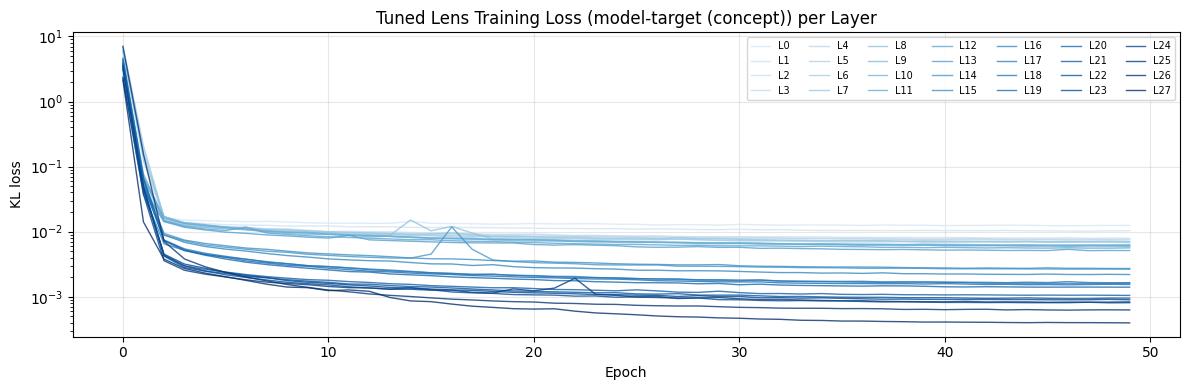

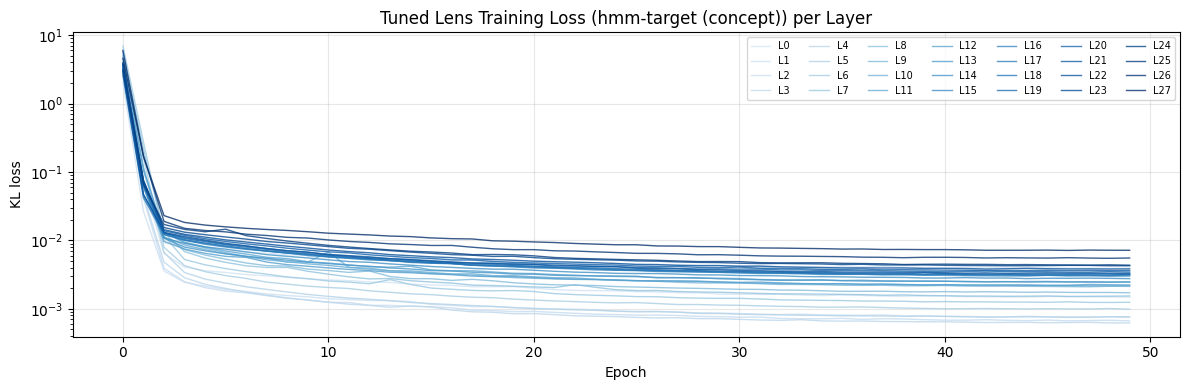

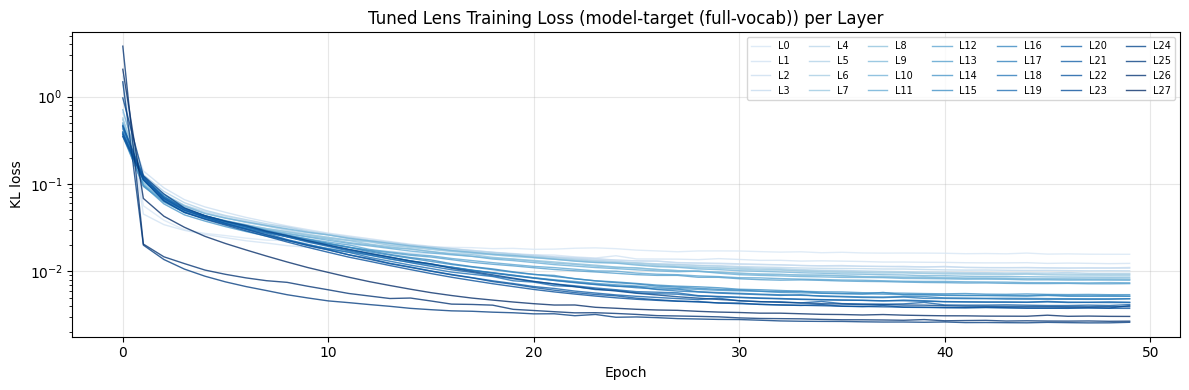

In [45]:
def plot_losses(training_losses, layers, label):    
    fig, ax = plt.subplots(figsize=(12, 4))
    cmap = plt.cm.Blues
    norm = plt.Normalize(vmin=min(layers) - 5, vmax=max(layers))
    for layer in layers:
        ax.plot(training_losses[layer], alpha=0.8, linewidth=1,
                label=f'L{layer}', color=cmap(norm(layer)))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL loss")
    ax.set_title(f"Tuned Lens Training Loss ({label}) per Layer")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=7, fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.show()

plot_losses(training_losses, LAYERS_TO_ANALYZE, label="model-target (concept)")
plot_losses(losses_hmm, LAYERS_TO_ANALYZE, label="hmm-target (concept)")
plot_losses(losses_fv, LAYERS_TO_ANALYZE, label="model-target (full-vocab)")

In [61]:
def evaluate_tuned_lens(translators, label=""):
    """Evaluate TunedLensTranslators (concept-only output) over all layers."""
    probs_by_layer   = {}
    kl_hmm_mean      = {}
    kl_hmm_all       = {}
    kl_vs_model_mean = {}

    desc = f"Evaluating tuned lens{' (' + label + ')' if label else ''}"
    with torch.no_grad():
        for layer in tqdm(LAYERS_TO_ANALYZE, desc=desc):
            translator = translators[layer].to(_unembed_device)
            acts       = torch.tensor(all_activations[layer], dtype=torch.float32)
            n          = acts.shape[0]
            probs_list = []

            for start in range(0, n, _BATCH):
                batch         = acts[start : start + _BATCH].to(_unembed_device)
                h             = translator(batch)
                normed        = model.ln_final(h)
                concept_logit = normed @ W_concept + b_concept
                probs_list.append(F.softmax(concept_logit, dim=-1).cpu().numpy())

            probs = np.concatenate(probs_list, axis=0)
            probs_by_layer[layer] = probs

            q = np.clip(probs / probs.sum(1, keepdims=True), _EPS, 1.0)

            p   = np.clip(hmm_probs_flat, _EPS, 1.0)
            kl  = np.sum(p * np.log(p / q), axis=-1)
            kl_hmm_mean[layer] = float(kl.mean())
            kl_hmm_all[layer]  = kl

            p_m  = np.clip(_model_concept_probs, _EPS, 1.0)
            kl_m = np.sum(p_m * np.log(p_m / q), axis=-1)
            kl_vs_model_mean[layer] = float(kl_m.mean())

            translator.cpu()

    torch.cuda.empty_cache()
    return probs_by_layer, kl_hmm_mean, kl_hmm_all, kl_vs_model_mean


def evaluate_tuned_lens_full_vocab(translators_fv, concept_ids, hmm_probs_flat, all_logits_flat, label=""):
    """
    Evaluate full-vocab tuned lens translators (d_model → d_model).
    Projects through the model's unembed to get full-vocab logits,
    takes softmax over all vocab IN FP32, then slices concept_ids for comparison.
    """
    probs_by_layer   = {}
    kl_hmm_mean      = {}
    kl_hmm_all       = {}
    kl_vs_model_mean = {}

    # Reference: model's concept probs via full-vocab softmax (fp32)
    model_concept_probs = F.softmax(
        torch.tensor(all_logits_flat, dtype=torch.float32), dim=-1
    )[:, concept_ids].numpy()

    W_U = model.unembed.W_U.detach()   # (d_model, vocab_size)
    b_U = model.unembed.b_U.detach()   # (vocab_size,)

    desc = f"Evaluating full-vocab tuned lens{' (' + label + ')' if label else ''}"
    with torch.no_grad():
        for layer in tqdm(LAYERS_TO_ANALYZE, desc=desc):
            translator = translators_fv[layer].to(_unembed_device)
            acts       = torch.tensor(all_activations[layer], dtype=torch.float32)
            n          = acts.shape[0]
            probs_list = []

            for start in range(0, n, _BATCH):
                batch  = acts[start : start + _BATCH].to(_unembed_device)
                h      = translator(batch)                        # (B, d_model)
                normed = model.ln_final(h)                        # (B, d_model)
                logits = normed @ W_U + b_U                       # (B, vocab_size)
                # fp32 softmax to avoid fp16 zero-rounding on small probs
                full_probs = F.softmax(logits.float(), dim=-1)    # (B, vocab_size) fp32
                concept_probs = full_probs[:, concept_ids]        # (B, K)
                probs_list.append(concept_probs.cpu().numpy())

            probs = np.concatenate(probs_list, axis=0)
            probs_by_layer[layer] = probs

            q = np.clip(probs, _EPS, 1.0)

            p   = np.clip(hmm_probs_flat, _EPS, 1.0)
            kl  = np.sum(p * np.log(p / q), axis=-1)
            kl_hmm_mean[layer] = float(kl.mean())
            kl_hmm_all[layer]  = kl

            p_m  = np.clip(model_concept_probs, _EPS, 1.0)
            kl_m = np.sum(p_m * np.log(p_m / q), axis=-1)
            kl_vs_model_mean[layer] = float(kl_m.mean())

            translator.cpu()

    torch.cuda.empty_cache()
    return probs_by_layer, kl_hmm_mean, kl_hmm_all, kl_vs_model_mean


# Evaluate concept-only tuned lenses
(tuned_lens_probs, tuned_lens_kl_mean, tuned_lens_kl_all,
 tuned_lens_kl_vs_model_mean) = evaluate_tuned_lens(tuned_lens_translators, label="model-target")

(tuned_lens_hmm_probs, tuned_lens_hmm_kl_mean, tuned_lens_hmm_kl_all,
 tuned_lens_hmm_kl_vs_model_mean) = evaluate_tuned_lens(tuned_lens_translators_hmm, label="HMM-target")

# Evaluate full-vocab tuned lens
(tuned_lens_fv_probs, tuned_lens_fv_kl_mean, tuned_lens_fv_kl_all,
 tuned_lens_fv_kl_vs_model_mean) = evaluate_tuned_lens_full_vocab(
    tuned_lens_translators_fv, concept_ids, hmm_probs_flat, all_logits_flat, label="full-vocab"
)

Evaluating full-vocab tuned lens (full-vocab): 100%|██████████| 28/28 [01:36<00:00,  3.44s/it]


In [62]:
def print_kl_table(lens_kl_vs_model, lens_kl_hmm, label):
    print(f"\n=== {label} ===")
    print("KL(model_concept ‖ lens) per layer  [lower = lens better approximates model]")
    print(f"{'Layer':>7s}  {'Logit Lens':>10s}  {'Tuned Lens':>10s}  {'Δ':>8s}")
    print("-" * 42)
    kl_vs_model_list = []
    kl_hmm_list = []
    for l in LAYERS_TO_ANALYZE:
        ll    = logit_lens_kl_vs_model_mean[l]
        tl    = lens_kl_vs_model[l]
        delta = tl - ll
        sign  = "↓" if delta < 0 else "↑"
        print(f"  {l:5d}  {ll:10.4f}  {tl:10.4f}  {delta:+7.4f} {sign}")
        kl_vs_model_list.append(tl)
        kl_hmm_list.append(lens_kl_hmm[l])

    print("\nKL(HMM ‖ lens) per layer")
    print(f"{'Layer':>7s}  {'Logit Lens':>10s}  {'Tuned Lens':>10s}  {'Model':>10s}")
    print("-" * 50)
    _model_kl = float(np.sum(
        np.clip(hmm_probs_flat, _EPS, 1.0) *
        np.log(np.clip(hmm_probs_flat, _EPS, 1.0) / np.clip(_model_concept_probs, _EPS, 1.0)),
        axis=-1
    ).mean())
    for l in LAYERS_TO_ANALYZE:
        print(f"  {l:5d}  {logit_lens_kl_mean[l]:10.4f}  {lens_kl_hmm[l]:10.4f}  {_model_kl:10.4f}")
    print(f"\n  Model baseline KL(HMM ‖ model) = {_model_kl:.4f}")
    return kl_vs_model_list, kl_hmm_list


kl_vs_model_model_target, kl_hmm_model_target = print_kl_table(
    tuned_lens_kl_vs_model_mean, tuned_lens_kl_mean, "Model-target lens (concept)"
)
kl_vs_model_hmm_target, kl_hmm_hmm_target = print_kl_table(
    tuned_lens_hmm_kl_vs_model_mean, tuned_lens_hmm_kl_mean, "HMM-target lens (concept)"
)
kl_vs_model_fv_target, kl_hmm_fv_target = print_kl_table(
    tuned_lens_fv_kl_vs_model_mean, tuned_lens_fv_kl_mean, "Model-target lens (full-vocab)"
)


=== Model-target lens (concept) ===
KL(model_concept ‖ lens) per layer  [lower = lens better approximates model]
  Layer  Logit Lens  Tuned Lens         Δ
------------------------------------------
      0         inf      0.0124     -inf ↓
      1         inf      0.0103     -inf ↓
      2         inf      0.0080     -inf ↓
      3      1.7038      0.0077  -1.6961 ↓
      4      1.0161      0.0075  -1.0086 ↓
      5      1.2063      0.0068  -1.1995 ↓
      6      1.1018      0.0069  -1.0949 ↓
      7      0.9987      0.0070  -0.9916 ↓
      8      0.7483      0.0062  -0.7421 ↓
      9      0.5989      0.0060  -0.5929 ↓
     10      0.5257      0.0062  -0.5196 ↓
     11      0.3226      0.0060  -0.3166 ↓
     12      0.2632      0.0056  -0.2576 ↓
     13      0.2764      0.0051  -0.2713 ↓
     14      0.3111      0.0027  -0.3084 ↓
     15      0.3126      0.0027  -0.3098 ↓
     16      0.6955      0.0022  -0.6933 ↓
     17      0.5513      0.0016  -0.5497 ↓
     18      0.6275      0.

In [63]:
def plot_tuned_lens_results(
    layers_sorted,
    kl_logit,
    kl_tuned,             # KL(HMM ‖ model-target lens)
    kl_tuned_vs_model,    # KL(model ‖ model-target lens)
    kl_tuned_hmm,         # KL(HMM ‖ HMM-target lens)
    kl_tuned_hmm_vs_model,# KL(model ‖ HMM-target lens)
    kl_tuned_fv,          # KL(HMM ‖ full-vocab lens)
    kl_tuned_fv_vs_model, # KL(model ‖ full-vocab lens)
    mse_main,
    title="Tuned Lens – Llama-3.2-3B on Mess3 HMM (a=0.85, x=0.05)",
    save_dir=None,):
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        
        # ── Panel 1: KL(HMM ‖ lens) by layer ─────────────────────────────────
        ax = axes[0]
        ax.plot(layers_sorted, kl_tuned,     "o-", color="steelblue", linewidth=2,
                label="KL(HMM ‖ tuned_concept)")
        ax.plot(layers_sorted, kl_tuned_hmm, "o-", color="green",     linewidth=2,
                label="KL(HMM ‖ tuned_hmm)")
        ax.plot(layers_sorted, kl_tuned_fv,  "o-", color="purple",    linewidth=2,
                label="KL(HMM ‖ tuned_fullvocab)")
        ax.plot(layers_sorted, kl_tuned_vs_model, "o-", color="darkorange", linewidth=2,
                label="KL(model ‖ tuned_concept)")
        ax.plot(layers_sorted, kl_tuned_fv_vs_model, "o-", color="magenta", linewidth=2,
                label="KL(model ‖ tuned_fullvocab)")
        ax.axhline(kl_logit[-1], color="grey", linestyle="--", linewidth=1,
                   label=f"Logit lens (layer {layers_sorted[-1]})")
        ax.set_xlabel("Layer"); ax.set_ylabel("KL")
        ax.set_title("KL Divergence by Layer")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # ── Panel 2: R² vs KL(HMM ‖ lens) ────────────────────────────────────
        ax1 = axes[1]; ax2 = ax1.twinx()
        ax1.plot(layers_sorted, mse_main, "o-", color="black", linewidth=2, label="R² (linear probe)")
        ax2.plot(layers_sorted, kl_tuned,    "s--", color="steelblue", linewidth=2, label="KL(HMM ‖ tuned_concept)")
        ax2.plot(layers_sorted, kl_tuned_hmm,"s--", color="green",     linewidth=2, label="KL(HMM ‖ tuned_hmm)")
        ax2.plot(layers_sorted, kl_tuned_fv, "s--", color="purple",    linewidth=2, label="KL(HMM ‖ tuned_fullvocab)")
        ax1.set_xlabel("Layer")
        ax1.set_ylabel("R² (linear probe → belief state)", color="steelblue")
        ax2.set_ylabel("KL(HMM ‖ tuned lens)", color="darkorange")
        ax1.tick_params(axis="y", labelcolor="steelblue")
        ax2.tick_params(axis="y", labelcolor="darkorange")
        ax1.set_title("Belief-State R² vs Tuned-Lens KL per Layer")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper left")
        ax1.grid(True, alpha=0.3)

        # ── Panel 3: KL(model ‖ lens) comparison ──────────────────────────────
        ax = axes[2]
        ax.plot(layers_sorted, kl_tuned_vs_model,     "o-", color="darkorange", linewidth=2,
                label="KL(model ‖ tuned_concept)")
        ax.plot(layers_sorted, kl_tuned_hmm_vs_model, "o-", color="red",        linewidth=2,
                label="KL(model ‖ tuned_hmm)")
        ax.plot(layers_sorted, kl_tuned_fv_vs_model,  "o-", color="magenta",    linewidth=2,
                label="KL(model ‖ tuned_fullvocab)")
        ax.set_xlabel("Layer"); ax.set_ylabel("KL")
        ax.set_title("KL(model ‖ lens): Concept vs HMM vs Full-Vocab")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        plt.suptitle(title, fontsize=11, y=1.02)
        plt.tight_layout()
        plt.show()

        print(f"\n{'Layer':>5}  {'R²':>10}  {'KL logit':>10}  {'KL concept':>10}  {'KL hmm':>10}  {'KL fullvocab':>12}")
        print("-" * 68)
        for i, l in enumerate(layers_sorted):
            print(f"{l:5d}  {mse_main[i]:10.5f}  {kl_logit[i]:10.5f}  {kl_tuned[i]:10.5f}  {kl_tuned_hmm[i]:10.5f}  {kl_tuned_fv[i]:12.5f}")

        if save_dir is not None:
            from pathlib import Path
            out = Path(save_dir)
            out.mkdir(exist_ok=True)
            fig.savefig(out / "tuned_lens_comparison.png", dpi=150, bbox_inches="tight")
            fig.savefig(out / "tuned_lens_comparison.pdf", bbox_inches="tight")

        return fig

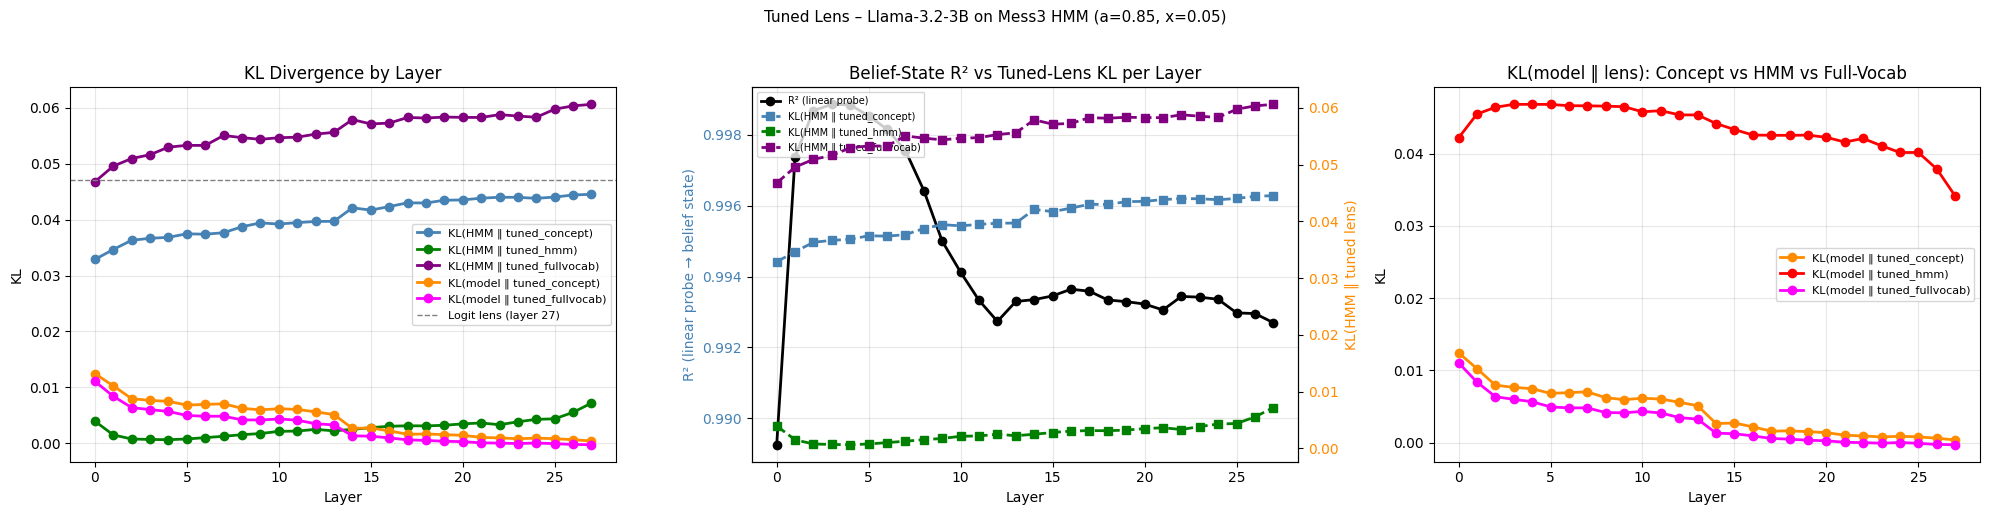


Layer          R²    KL logit  KL concept      KL hmm  KL fullvocab
--------------------------------------------------------------------
    0     0.98926         inf     0.03287     0.00394       0.04677
    1     0.99738         inf     0.03466     0.00149       0.04957
    2     0.99868         inf     0.03631     0.00075       0.05093
    3     0.99885     1.48823     0.03665     0.00067       0.05161
    4     0.99884     0.88822     0.03684     0.00063       0.05297
    5     0.99853     1.21000     0.03746     0.00075       0.05329
    6     0.99815     1.16082     0.03739     0.00100       0.05327
    7     0.99755     1.07429     0.03766     0.00124       0.05505
    8     0.99642     0.81641     0.03873     0.00152       0.05467
    9     0.99500     0.63399     0.03941     0.00173       0.05437
   10     0.99412     0.56851     0.03921     0.00212       0.05465
   11     0.99333     0.34815     0.03946     0.00217       0.05475
   12     0.99273     0.27232     0.03967     

In [64]:
fig = plot_tuned_lens_results(
    layers_sorted         = sorted(LAYERS_TO_ANALYZE),
    kl_logit              = [logit_lens_kl_mean[l] for l in sorted(LAYERS_TO_ANALYZE)],
    kl_tuned              = kl_hmm_model_target,
    kl_tuned_vs_model     = kl_vs_model_model_target,
    kl_tuned_hmm          = kl_hmm_hmm_target,
    kl_tuned_hmm_vs_model = kl_vs_model_hmm_target,
    kl_tuned_fv           = kl_hmm_fv_target,
    kl_tuned_fv_vs_model  = kl_vs_model_fv_target,
    mse_main              = [regression_results_main[l]['r2_test'] for l in sorted(LAYERS_TO_ANALYZE)],
    save_dir              = "figures",
)